In [ ]:
import pandas as pd

from main import *

logger = CustomLogger(name="jas_test", log_file_name='jas_test.log').get_logger()


In [ ]:
number_mimo = 1
is_mimo = number_mimo > 1
y_is_flat = not is_mimo

l_min = 4
max_diff = 3
c_thresh = 0.9

df = add_features_and_filter(l_min, max_diff, c_thresh, read_from_integrated=False)
logger.info(f"Csv file has bean labeled successfully")

# ds = Data_selector(df)
# df_modified = ds.select_peaks(goodness=3)
# logger.info(f"Rows have been selected successfully")

feature_selector = Feature_selector(df, target="generation")
features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                         "status", "season", "is_good_peak"] + ["datetime"]
# for hour in range(1, 4):
#     features_to_be_select.append(f"generation_with_{hour}_delay")
# features_to_be_select.append(f"generation_with_{24}_delay")
feature_selector.select(features_to_select=features_to_be_select)
X, y = feature_selector.get_X_and_y(is_mimo=is_mimo, number_mimo=number_mimo)
logger.info(f"Some features have been dropped successfully")

ds = Data_selector(X)
X_filtered = ds.select_peaks(goodness=3)
y_filtered = y[X_filtered.index]

model = XGBoost(n_estimators=1000, max_depth=5)
model.scale_and_split_data(X_filtered, y_filtered, y_is_flat=y_is_flat, do_scale=False)
model.fit()
logger.info(f"Model has been trained successfully")

test_model(model, do_inverse_scale=False)



In [ ]:
df["semi_prediction1"] = model.pred(X, do_scale=False)
# df.loc[X_filtered.index, "semi_prediction1"] = df.loc[X_filtered.index, "generation"]


In [ ]:
number_mimo = 1
is_mimo = number_mimo > 1
y_is_flat = not is_mimo

l_min = 4
max_diff = 3
c_thresh = 0.9

logger.info(f"Csv file has bean labeled successfully")

# ds = Data_selector(df)
# df_modified = ds.select_peaks(goodness=3)
# logger.info(f"Rows have been selected successfully")

feature_selector = Feature_selector(df, target="generation")
features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                         "status", "season", "is_good_peak"] + ["datetime"]
# for hour in range(1, 4):
#     features_to_be_select.append(f"generation_with_{hour}_delay")
# features_to_be_select.append(f"generation_with_{24}_delay")
features_to_be_select.append(f"semi_prediction1")
feature_selector.select(features_to_select=features_to_be_select)
X, y = feature_selector.get_X_and_y(is_mimo=is_mimo, number_mimo=number_mimo)
logger.info(f"Some features have been dropped successfully")

ds = Data_selector(X)
X_filtered = ds.select_peaks(goodness=3)
y_filtered = y[X_filtered.index]

model = XGBoost(n_estimators=2000, max_depth=7)
model.scale_and_split_data(X_filtered, y_filtered, y_is_flat=y_is_flat, do_scale=False)
model.fit()
logger.info(f"Model has been trained successfully")

test_model(model, do_inverse_scale=False)


In [ ]:
df["semi_prediction2"] = model.pred(X, do_scale=False)
# df.loc[X_filtered.index, "semi_prediction"] = df.loc[X_filtered.index, "generation"]


In [ ]:
number_mimo = 4
is_mimo = number_mimo > 1
y_is_flat = not is_mimo

l_min = 4
max_diff = 3
c_thresh = 0.9

feature_adder = Feature_adder(df, add_label_column=False)
for hour in range(1, 4):
    feature_adder.create_feature_with_delay("semi_prediction1", hour)
df1 = feature_adder.df

ds = Data_selector(df1)
df_modified = ds.select_peaks(goodness=3)
logger.info(f"Rows have been selected successfully")

feature_selector = Feature_selector(df_modified, target="generation")
features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                         "status", "season"] + ["datetime"]
# for hour in range(1, 4):
#     features_to_be_select.append(f"semi_prediction1_with_{hour}_delay")
features_to_be_select.append(f"semi_prediction1")
features_to_be_select.append(f"generation_with_{24}_delay")
feature_selector.select(features_to_select=features_to_be_select)
X, y = feature_selector.get_X_and_y(is_mimo=is_mimo, number_mimo=number_mimo)
logger.info(f"Some features have been dropped successfully")


In [ ]:
model = XGBoost(n_estimators=1000, max_depth=5)
model.scale_and_split_data(X, y, y_is_flat=y_is_flat, do_scale=False)
model.fit()
logger.info(f"Model has been trained successfully")

test_model(model, do_inverse_scale=False)


In [56]:
from main import *

logger = CustomLogger(name="jas_test", log_file_name='jas_test.log').get_logger()

l_min = 4
max_diff = 3
c_thresh = 0.9

number_mimo = 1
is_mimo = number_mimo > 1
y_is_flat = not is_mimo

df = add_features_and_filter(l_min, max_diff, c_thresh, read_from_integrated=False)
logger.info(f"Csv file has bean labeled successfully")

2025-09-22 11:50:47 - jas_test - INFO - Csv file has bean labeled successfully


In [57]:

n = 3
trains_index = []
for sp_version in range(n):
    feature_selector = Feature_selector(df, target="generation")
    features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                             "status", "season", "is_good_peak"] + ["datetime"]
    if sp_version > 0:
        features_to_be_select.append(f"semi_prediction{sp_version}")
    features_to_be_select.append(f"generation_with_{24}_delay")
    feature_selector.select(features_to_select=features_to_be_select)
    X, y = feature_selector.get_X_and_y(is_mimo=is_mimo, number_mimo=number_mimo)
    logger.info(f"Some features have been dropped successfully")

    ds = Data_selector(X)
    X_filtered = ds.select_peaks(goodness=3)
    y_filtered = y[X_filtered.index]

    model = XGBoost(n_estimators=2000, max_depth=7)
    model.scale_and_split_data(X_filtered, y_filtered, y_is_flat=y_is_flat, do_scale=False, random_state=24)
    # is_reset = model.X_train.index.equals(pd.RangeIndex(start=0,stop=len(model.X_train),step=1))
    # print(i,is_reset)
    trains_index.append(model.X_train.index)
    model.fit()
    
    logger.info(f"Model has been trained successfully")
    
    test_model(model, do_inverse_scale=False)

    df[f"semi_prediction{sp_version + 1}"] = model.pred(X, do_scale=False)

2025-09-22 11:50:48 - jas_test - INFO - Some features have been dropped successfully
2025-09-22 11:50:53 - jas_test - INFO - Model has been trained successfully
2025-09-22 11:50:53 - model_main - INFO - Train Error: 0.65%, Test Error: 1.79%
2025-09-22 11:50:57 - jas_test - INFO - Some features have been dropped successfully
2025-09-22 11:51:03 - jas_test - INFO - Model has been trained successfully
2025-09-22 11:51:03 - model_main - INFO - Train Error: 0.28%, Test Error: 1.76%
2025-09-22 11:51:06 - jas_test - INFO - Some features have been dropped successfully
2025-09-22 11:51:11 - jas_test - INFO - Model has been trained successfully
2025-09-22 11:51:11 - model_main - INFO - Train Error: 0.17%, Test Error: 1.77%
2025-09-22 11:51:15 - jas_test - INFO - Some features have been dropped successfully
2025-09-22 11:51:20 - jas_test - INFO - Model has been trained successfully
2025-09-22 11:51:20 - model_main - INFO - Train Error: 0.11%, Test Error: 1.77%
2025-09-22 11:51:23 - jas_test - INF

In [58]:
number_mimo = 4
is_mimo = number_mimo > 1
y_is_flat = not is_mimo

l_min = 4
max_diff = 3
c_thresh = 0.9

df1 = df.copy()

ds = Data_selector(df1)
df_modified = ds.select_peaks(goodness=3)
logger.info(f"Rows have been selected successfully")

for sp_version in range(4, 5):
    feature_selector = Feature_selector(df_modified, target="generation")
    features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                             "status", "season"] + ["datetime"]
    features_to_be_select.append(f"semi_prediction{sp_version}")
    features_to_be_select.append(f"generation_with_{24}_delay")
    feature_selector.select(features_to_select=features_to_be_select)
    X, y = feature_selector.get_X_and_y(is_mimo=is_mimo, number_mimo=number_mimo)
    logger.info(f"Some features have been dropped successfully")

    model = XGBoost(n_estimators=2000, max_depth=7)
    model.scale_and_split_data(X, y, y_is_flat=y_is_flat, do_scale=False, random_state=24)
    model.fit()
    logger.info(f"Model has been trained successfully")

    logger.info(f"semi_prediction: {sp_version}")
    test_model(model, do_inverse_scale=False)
    
    


2025-09-22 11:51:31 - jas_test - INFO - Rows have been selected successfully
2025-09-22 11:51:38 - jas_test - INFO - Some features have been dropped successfully
2025-09-22 11:52:03 - jas_test - INFO - Model has been trained successfully
2025-09-22 11:52:03 - jas_test - INFO - semi_prediction: 4
2025-09-22 11:52:04 - model_main - INFO - Train Error: 0.09%, Test Error: 0.61%


In [ ]:
0.5, 0.61

In [ ]:
number_mimo = 4
is_mimo = number_mimo > 1
y_is_flat = not is_mimo

l_min = 4
max_diff = 3
c_thresh = 0.9

sp_version = 4
train_errors = []
test_errors = []

df1 = df.copy()
ds = Data_selector(df1)
df_modified = ds.select_peaks(goodness=3)
power_plants = df_modified[['name', 'code']].drop_duplicates()
for _, row in power_plants.iterrows():
    name = row['name']
    code = row['code']
    df_name_code = Data_selector(df_modified).filter_name_code(name, code)
    logger.info(f"Rows have been selected successfully")
    
    feature_selector = Feature_selector(df_name_code, target="generation")
    features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                             "status", "season"] + ["datetime"]
    features_to_be_select.append(f"semi_prediction{sp_version}")
    features_to_be_select.append(f"generation_with_{24}_delay")
    feature_selector.select(features_to_select=features_to_be_select)
    X, y = feature_selector.get_X_and_y(is_mimo=is_mimo, number_mimo=number_mimo)
    logger.info(f"Some features have been dropped successfully")

    model = XGBoost(n_estimators=200, max_depth=5)
    model.scale_and_split_data(X, y, y_is_flat=y_is_flat, do_scale=False)
    model.fit()
    logger.info(f"Model has been trained successfully")
    
    logger.info(f"n_est: {n}")
    rmse_error_train, rmse_error_test = model.rescale_and_compute_error(do_inverse_scale=False)
    logger.info(f"Train Error: {rmse_error_train:0.2f}%, Test Error: {rmse_error_test:0.2f}%")
    train_errors.append(rmse_error_train)
    test_errors.append(rmse_error_test)

In [ ]:
import matplotlib.pyplot as plt

# plt.plot(train_errors, label="train_errors")
plt.plot(test_errors, label="test_errors")

plt.legend()
plt.show()

In [51]:
train_errors1 = []
test_errors1 = []

power_plants = df_modified[['name', 'code']].drop_duplicates()
for n in range(10, 500, 40):
    i = 26
    name = power_plants.iloc[i]['name']
    code = power_plants.iloc[i]['code']
    df_name_code = Data_selector(df_modified).filter_name_code(name, code)
    logger.info(f"Rows have been selected successfully")

    feature_selector = Feature_selector(df_name_code, target="generation")
    features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                             "status", "season"] + ["datetime"]
    features_to_be_select.append(f"semi_prediction{sp_version}")
    features_to_be_select.append(f"generation_with_{24}_delay")
    feature_selector.select(features_to_select=features_to_be_select)
    X, y = feature_selector.get_X_and_y(is_mimo=is_mimo, number_mimo=number_mimo)
    logger.info(f"Some features have been dropped successfully")

    model = XGBoost(n_estimators=n, max_depth=2)
    model.scale_and_split_data(X, y, y_is_flat=y_is_flat, do_scale=False)
    model.fit()
    logger.info(f"Model has been trained successfully")

    logger.info(f"n_est: {n}")
    rmse_error_train, rmse_error_test = model.rescale_and_compute_error(do_inverse_scale=False)
    logger.info(f"Train Error: {rmse_error_train:0.2f}%, Test Error: {rmse_error_test:0.2f}%")
    train_errors1.append(rmse_error_train)
    test_errors1.append(rmse_error_test)

2025-09-22 11:40:39 - jas_test - INFO - Rows have been selected successfully
2025-09-22 11:40:39 - jas_test - INFO - Some features have been dropped successfully
2025-09-22 11:40:39 - jas_test - INFO - Model has been trained successfully
2025-09-22 11:40:39 - jas_test - INFO - n_est: 10
2025-09-22 11:40:39 - jas_test - INFO - Train Error: 1.62%, Test Error: 3.75%
2025-09-22 11:40:39 - jas_test - INFO - Rows have been selected successfully
2025-09-22 11:40:39 - jas_test - INFO - Some features have been dropped successfully
2025-09-22 11:40:39 - jas_test - INFO - Model has been trained successfully
2025-09-22 11:40:39 - jas_test - INFO - n_est: 50
2025-09-22 11:40:39 - jas_test - INFO - Train Error: 0.40%, Test Error: 2.79%
2025-09-22 11:40:39 - jas_test - INFO - Rows have been selected successfully
2025-09-22 11:40:39 - jas_test - INFO - Some features have been dropped successfully
2025-09-22 11:40:40 - jas_test - INFO - Model has been trained successfully
2025-09-22 11:40:40 - jas_test

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_errors1, label="train_errors")
plt.plot(test_errors1, label="test_errors")

plt.legend()
plt.show()


In [ ]:
12, 14, 22, 26, 32

In [36]:
len(df_name_code)

511

In [1]:
from main import *

logger = CustomLogger(name="jas_test", log_file_name='jas_test.log').get_logger()




2025-09-22 11:58:19 - jas_test - INFO - Csv file has bean labeled successfully


In [3]:
errors = []

for rs in range(24, 43):
    print("random state:", rs)
    l_min = 4
    max_diff = 3
    c_thresh = 0.9
    
    number_mimo = 1
    is_mimo = number_mimo > 1
    y_is_flat = not is_mimo
    
    df = add_features_and_filter(l_min, max_diff, c_thresh, read_from_integrated=False)
    logger.info(f"Csv file has bean labeled successfully")
    n = 4
    for sp_version in range(n):
        feature_selector = Feature_selector(df, target="generation")
        features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                                 "status", "season", "is_good_peak"] + ["datetime"]
        if sp_version > 0:
            features_to_be_select.append(f"semi_prediction{sp_version}")
        features_to_be_select.append(f"generation_with_{24}_delay")
        feature_selector.select(features_to_select=features_to_be_select)
        X, y = feature_selector.get_X_and_y(is_mimo=is_mimo, number_mimo=number_mimo)
        
        ds = Data_selector(X)
        X_filtered = ds.select_peaks(goodness=3)
        y_filtered = y[X_filtered.index]
    
        model = XGBoost(n_estimators=2000, max_depth=7)
        model.scale_and_split_data(X_filtered, y_filtered, y_is_flat=y_is_flat, do_scale=False, random_state=rs)
        model.fit()
        
        test_model(model, do_inverse_scale=False)
    
        df[f"semi_prediction{sp_version + 1}"] = model.pred(X, do_scale=False)
        
    number_mimo = 4
    is_mimo = number_mimo > 1
    y_is_flat = not is_mimo
    
    df1 = df.copy()
    
    ds = Data_selector(df1)
    df_modified = ds.select_peaks(goodness=3)
    
    sp_version = 4
    feature_selector = Feature_selector(df_modified, target="generation")
    features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                             "status", "season"] + ["datetime"]
    features_to_be_select.append(f"semi_prediction{sp_version}")
    features_to_be_select.append(f"generation_with_{24}_delay")
    feature_selector.select(features_to_select=features_to_be_select)
    X, y = feature_selector.get_X_and_y(is_mimo=is_mimo, number_mimo=number_mimo)    
    model = XGBoost(n_estimators=2000, max_depth=7)
    model.scale_and_split_data(X, y, y_is_flat=y_is_flat, do_scale=False, random_state=rs)
    model.fit()    
    rmse_error_train, rmse_error_test = model.rescale_and_compute_error(do_inverse_scale=False)
    logger.info(f"#Train Error: {rmse_error_train:0.2f}%, Test Error: {rmse_error_test:0.2f}%")
    errors.append(rmse_error_test)

random state: 24


2025-09-22 12:43:33 - jas_test - INFO - Csv file has bean labeled successfully
2025-09-22 12:43:43 - model_main - INFO - Train Error: 0.65%, Test Error: 1.79%
2025-09-22 12:43:52 - model_main - INFO - Train Error: 0.28%, Test Error: 1.76%
2025-09-22 12:44:00 - model_main - INFO - Train Error: 0.17%, Test Error: 1.77%
2025-09-22 12:44:09 - model_main - INFO - Train Error: 0.11%, Test Error: 1.77%
2025-09-22 12:44:44 - jas_test - INFO - #Train Error: 0.09%, Test Error: 0.61%


random state: 25


2025-09-22 12:44:50 - jas_test - INFO - Csv file has bean labeled successfully
2025-09-22 12:44:56 - model_main - INFO - Train Error: 0.64%, Test Error: 1.83%
2025-09-22 12:45:09 - model_main - INFO - Train Error: 0.28%, Test Error: 1.78%
2025-09-22 12:45:31 - model_main - INFO - Train Error: 0.16%, Test Error: 1.79%
2025-09-22 12:45:40 - model_main - INFO - Train Error: 0.11%, Test Error: 1.87%
2025-09-22 12:46:17 - jas_test - INFO - #Train Error: 0.09%, Test Error: 0.55%


random state: 26


...

2025-09-22 13:09:36 - jas_test - INFO - Csv file has bean labeled successfully
2025-09-22 13:09:42 - model_main - INFO - Train Error: 0.65%, Test Error: 1.83%
2025-09-22 13:09:50 - model_main - INFO - Train Error: 0.28%, Test Error: 1.79%
2025-09-22 13:09:59 - model_main - INFO - Train Error: 0.16%, Test Error: 1.80%
2025-09-22 13:10:07 - model_main - INFO - Train Error: 0.11%, Test Error: 1.84%
2025-09-22 13:10:43 - jas_test - INFO - #Train Error: 0.09%, Test Error: 0.55%


random state: 41


2025-09-22 13:10:49 - jas_test - INFO - Csv file has bean labeled successfully
2025-09-22 13:10:55 - model_main - INFO - Train Error: 0.65%, Test Error: 1.72%
2025-09-22 13:11:03 - model_main - INFO - Train Error: 0.28%, Test Error: 1.76%
2025-09-22 13:11:12 - model_main - INFO - Train Error: 0.16%, Test Error: 1.76%
2025-09-22 13:11:20 - model_main - INFO - Train Error: 0.11%, Test Error: 1.77%
2025-09-22 13:11:56 - jas_test - INFO - #Train Error: 0.09%, Test Error: 0.56%


random state: 42


2025-09-22 13:12:03 - jas_test - INFO - Csv file has bean labeled successfully
2025-09-22 13:12:09 - model_main - INFO - Train Error: 0.65%, Test Error: 1.80%
2025-09-22 13:12:17 - model_main - INFO - Train Error: 0.28%, Test Error: 1.81%
2025-09-22 13:12:26 - model_main - INFO - Train Error: 0.16%, Test Error: 1.83%
2025-09-22 13:12:35 - model_main - INFO - Train Error: 0.11%, Test Error: 1.83%
2025-09-22 13:13:12 - jas_test - INFO - #Train Error: 0.10%, Test Error: 0.50%


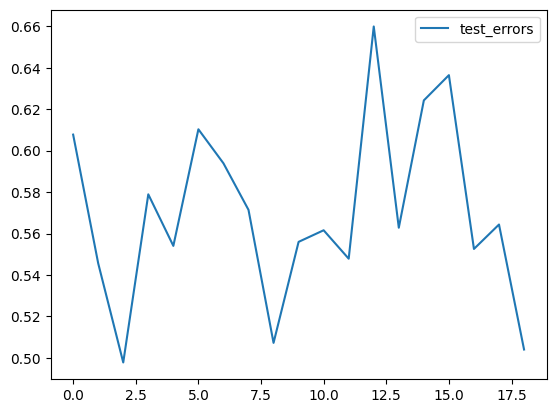

In [4]:
import matplotlib.pyplot as plt

plt.plot(errors, label="test_errors")

plt.legend()
plt.show()

In [12]:
import numpy as np
errors = np.array([round(float(e),2) for e in errors])
print(errors)

[0.61 0.55 0.5  0.58 0.55 0.61 0.59 0.57 0.51 0.56 0.56 0.55 0.66 0.56
 0.62 0.64 0.55 0.56 0.5 ]


In [15]:
max(errors), errors.mean(), min(errors)

(np.float64(0.66), np.float64(0.57), np.float64(0.5))